In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Проверяем формат столбцов

In [4]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [7]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [21]:
grouped_df =df.groupby('Дата', as_index=False)['Количество'].count()

Вывести несколько первых строк сгруппированных данных

In [22]:
grouped_df.reset_index().head(3)

,index,Дата,Количество
0,0,2018-01-04,1840
1,1,2018-01-05,1301
2,2,2018-01-06,1306


Нарисуйте график продаж у `grouped_df`

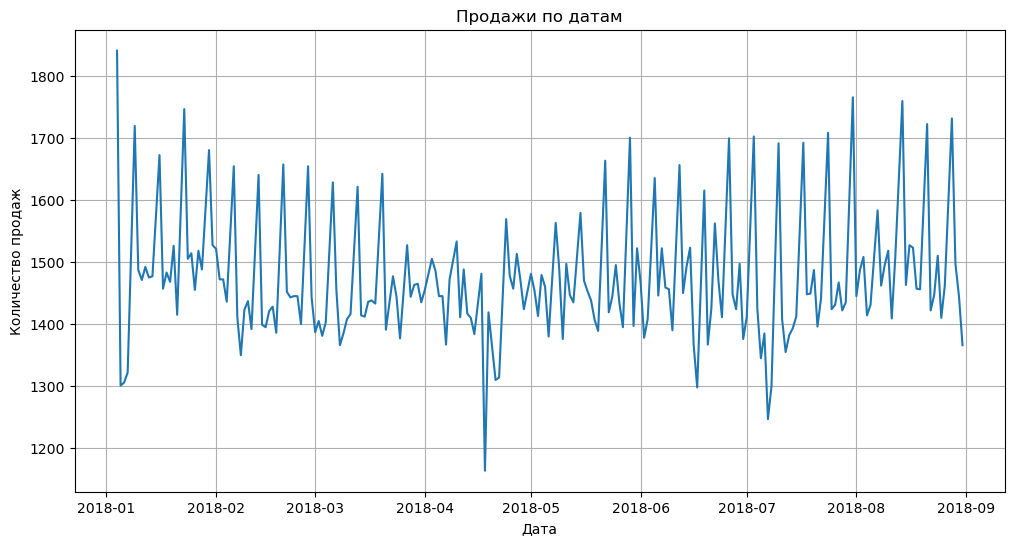

In [25]:
plt.figure(figsize=(12,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Мы видим на графике продажи товаров по датам: по оси X отображаются даты, по оси Y количество проданных товаров.
С января по май продажи держались примерно на одном уровне, колеблясь в диапазоне 1400–1500. 
Начиная с июня наблюдается плавный рост, средний уровень продаж увеличивается и достигает пиков в 1700–1800.
Также можно заметить выброс в начале января  вероятно, это связано с праздничными распродажами.
В середине апреля наблюдается резкое падение продаж почти до 1150. Это может быть связано с внешними факторами (например, праздниками, техническими сбоями или снижением спроса).
В целом, с июня прослеживается положительная динамика продажи постепенно растут.


Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [26]:
df[df['Количество'] == df['Количество'].max()]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [29]:
df_summer = df[df['Дата'].dt.month.isin([6,7,8])]
df_wed = df_summer[df_summer['Дата'].dt.weekday == 2]
top_product = (df_wed.groupby(['Склад','Номенклатура'])['Количество'].sum().reset_index())

top_product = top_product.sort_values(['Склад','Количество'], ascending=[True, False])
top_product.groupby('Склад').head(1)

,Склад,Номенклатура,Количество
1,1,product_1,2981
24,2,product_1,2887
46,3,product_1,2267
69,4,product_1,2385
92,5,product_1,1956


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [32]:
weather = pd.read_csv('Weather.csv')

In [33]:
weather.head()

,Местное время в Астане,T,Unnamed: 2
0,31.12.2018 23:00,-18.4,=
1,31.12.2018 20:00,-17.2,NaN
2,31.12.2018 17:00,-14.8,NaN
3,31.12.2018 14:00,-11.2,NaN
4,31.12.2018 11:00,-12.7,NaN


In [64]:
df= weather.drop(columns=['Unnamed: 2'])

In [65]:
df.head()

,Местное время в Астане,T
0,31.12.2018 23:00,-18.4
1,31.12.2018 20:00,-17.2
2,31.12.2018 17:00,-14.8
3,31.12.2018 14:00,-11.2
4,31.12.2018 11:00,-12.7


In [79]:
weather['Местное время в Астане'] = pd.to_datetime(weather['Местное время в Астане'])

weather['Дата'] = weather['Местное время в Астане'].dt.date

In [80]:
daily_temp = weather.groupby('Дата', as_index=False)['T'].mean()
daily_temp.columns = ['Дата', 'T']
print(daily_temp)

           Дата        T
0    2018-01-01  -9.4625
1    2018-01-02  -9.5125
2    2018-01-03 -11.4625
3    2018-01-04 -14.0750
4    2018-01-05 -16.8625
..          ...      ...
360  2018-12-27 -19.1000
361  2018-12-28 -13.2750
362  2018-12-29  -7.3250
363  2018-12-30  -9.9625
364  2018-12-31 -14.5500

[365 rows x 2 columns]


In [68]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date
merged= grouped_df.merge(daily_temp, on='Дата', how='left')

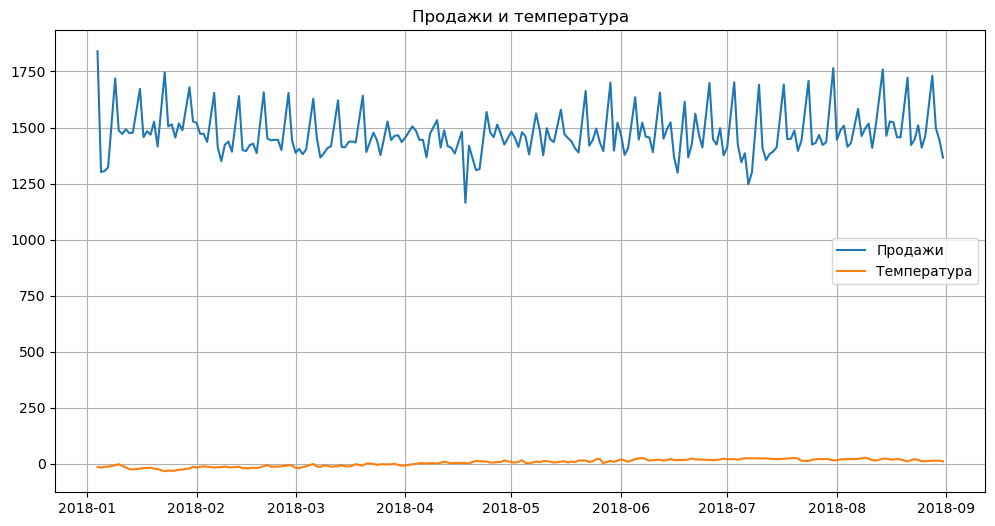

In [78]:
plt.figure(figsize=(12,6))
plt.plot(merged['Дата'], merged['Количество'], label='Продажи')
plt.plot(merged['Дата'], merged['T'], label='Температура')

plt.legend()
plt.title('Продажи и температура')
plt.grid()
plt.show()

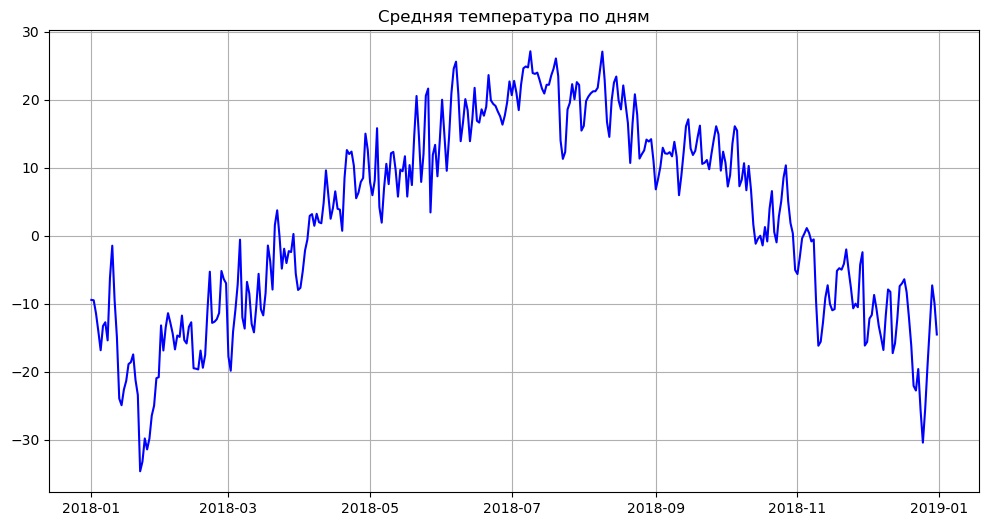

In [77]:
plt.figure(figsize=(12,6))
plt.plot(daily_temp['Дата'], daily_temp['T'], color='blue')
plt.title('Средняя температура по дням')
plt.grid()
plt.show()